# NeuroQWERTY v2: segmentation et features enrichies

Ce notebook teste une amelioration pragmatique de la baseline NeuroQWERTY: decouper les sessions en segments de frappes, extraire plus de features, predire au niveau segment, puis agreger les probabilites au niveau session.

Objectif: verifier si on peut ameliorer la generalisation par sujet sans fuite de donnees.

In [1]:
from pathlib import Path
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
RANDOM_STATE=42
sns.set_theme(style="whitegrid")
ROOT=Path.cwd()
if not (ROOT/'data'/'neuroqwerty-mit-csxpd-dataset-1.0.0').exists() and ROOT.name=='notebooks': ROOT=ROOT.parent
DATA_ROOT=ROOT/'data'/'neuroqwerty-mit-csxpd-dataset-1.0.0'
MODEL_DIR=ROOT/'models'; MODEL_DIR.mkdir(exist_ok=True)
print(ROOT)

/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection


## 1. Chargement et nettoyage

On garde le meme principe que le notebook 01: pas de dependance au loader Python 2, filtrage souris/meta/backspace, temps invalides retires.

In [2]:
KEY_COLUMNS=["key","hold_time","release_time","press_time"]
MOUSE_RE=re.compile(r'"?mouse.+"?', re.I)
LONG_META_RE=re.compile(r'"?(Shift.+|Alt.+|Control.+)"?', re.I)
BACKSPACE_RE=re.compile(r'"?BackSpace"?', re.I)
PUNCT_OR_SPACE_RE=re.compile(r'"?(space|comma|period|semicolon|slash|minus|equal|apostrophe|Return)"?', re.I)
LEFT_KEYS=set('qwertasdfgzxcvb')
RIGHT_KEYS=set('yuiophjklnm')

def load_raw(path):
    df=pd.read_csv(path, header=None, names=KEY_COLUMNS)
    df['key']=df['key'].astype(str).str.strip().str.replace('"','', regex=False)
    for c in ['hold_time','release_time','press_time']:
        df[c]=pd.to_numeric(df[c], errors='coerce')
    return df

def clean(df):
    d=df.dropna(subset=['hold_time','release_time','press_time']).copy()
    k=d['key'].astype(str)
    keep=~k.str.match(MOUSE_RE) & ~k.str.match(LONG_META_RE) & ~k.str.match(BACKSPACE_RE)
    d=d.loc[keep]
    d=d[(d.press_time>0)&(d.release_time>0)&(d.hold_time.between(0,5))]
    d=d.sort_values('press_time').reset_index(drop=True)
    d['flight_time']=d.press_time.diff()
    d.loc[d.flight_time<0,'flight_time']=np.nan
    d['is_space_punct']=d.key.str.match(PUNCT_OR_SPACE_RE).astype(int)
    d['hand_left']=d.key.str.lower().str[:1].isin(LEFT_KEYS).astype(int)
    d['hand_right']=d.key.str.lower().str[:1].isin(RIGHT_KEYS).astype(int)
    d['hand_switch']=(d.hand_left.diff().abs().fillna(0)>0).astype(int)
    return d

def load_sessions():
    rows=[]; raws={}
    for ds in ['MIT-CS1PD','MIT-CS2PD']:
        gt=pd.read_csv(DATA_ROOT/ds/f'GT_DataPD_{ds}.csv')
        raw_dir=DATA_ROOT/ds/f'data_{ds}'
        for _,s in gt.iterrows():
            for file_col in [c for c in gt.columns if c.startswith('file_')]:
                fn=s.get(file_col)
                if pd.isna(fn) or not str(fn).strip(): continue
                sid=f"{ds}_{int(s.pID)}_{file_col}"
                path=raw_dir/str(fn)
                d=clean(load_raw(path))
                raws[sid]=d
                rows.append({'session_uid':sid,'dataset':ds,'pID':int(s.pID),'session_file':str(fn),'session_id':file_col,'label':int(bool(s['gt'])),'n_keys':len(d)})
    return pd.DataFrame(rows), raws
sessions, raw_sessions = load_sessions()
print('sessions', len(sessions), 'subjects', sessions.pID.nunique())
display(sessions.groupby('label').agg(sessions=('label','size'), subjects=('pID','nunique')))

sessions 116 subjects 85


,sessions,subjects
label,,
0,56,43
1,60,42


## 2. Features enrichies et segmentation

On compare deux granularites:

- `session`: une ligne par session complete;
- `segment`: fenetres de 300 frappes avec stride 150, puis aggregation des probabilites par session.

Les features ajoutent asymetrie, kurtosis, coefficients de variation, pauses longues, quantiles, rythme et approximations gauche/droite.

In [3]:
def safe_div(a,b): return np.nan if b is None or pd.isna(b) or abs(b)<1e-12 else a/b

def entropy_binary(p):
    if pd.isna(p) or p<=0 or p>=1: return 0.0
    return -(p*np.log2(p)+(1-p)*np.log2(1-p))

def agg_features(d):
    ht=d.hold_time.dropna(); ft=d.flight_time.dropna(); dur=d.release_time.max()-d.press_time.min() if len(d) else np.nan
    out={
        'n_keystrokes':len(d),'duration_sec':dur,'keys_per_min':safe_div(len(d)*60,dur),
        'mean_hold':ht.mean(),'std_hold':ht.std(),'median_hold':ht.median(),'iqr_hold':ht.quantile(.75)-ht.quantile(.25),'q10_hold':ht.quantile(.1),'q90_hold':ht.quantile(.9),
        'skew_hold':ht.skew(),'kurt_hold':ht.kurt(),'cv_hold':safe_div(ht.std(), ht.mean()),
        'mean_flight':ft.mean(),'std_flight':ft.std(),'median_flight':ft.median(),'iqr_flight':ft.quantile(.75)-ft.quantile(.25),'q10_flight':ft.quantile(.1),'q90_flight':ft.quantile(.9),
        'skew_flight':ft.skew(),'kurt_flight':ft.kurt(),'cv_flight':safe_div(ft.std(), ft.mean()),
        'hold_to_flight':safe_div(ht.mean(), ft.mean()),
        'long_hold_rate':(ht>ht.quantile(.9)).mean() if len(ht)>5 else np.nan,
        'long_flight_rate':(ft>1.0).mean() if len(ft)>5 else np.nan,
        'space_punct_rate':d.is_space_punct.mean(),'left_rate':d.hand_left.mean(),'right_rate':d.hand_right.mean(),'hand_switch_rate':d.hand_switch.mean(),
    }
    out['hand_entropy']=entropy_binary(out['left_rate'])
    return out

def build_session_features():
    rows=[]
    for _,s in sessions.iterrows():
        rows.append({**s.to_dict(), **agg_features(raw_sessions[s.session_uid])})
    return pd.DataFrame(rows)

def build_segment_features(window=300, stride=150, min_len=120):
    rows=[]
    for _,s in sessions.iterrows():
        d=raw_sessions[s.session_uid]
        starts=list(range(0, max(len(d)-min_len+1,0), stride))
        for j,start in enumerate(starts):
            seg=d.iloc[start:min(start+window,len(d))]
            if len(seg)<min_len: continue
            rows.append({**s.to_dict(),'segment_id':j,'segment_start':start,'segment_len':len(seg), **agg_features(seg)})
    return pd.DataFrame(rows)

session_features=build_session_features()
segment_features=build_segment_features()
print('session_features', session_features.shape)
print('segment_features', segment_features.shape, 'sessions represented', segment_features.session_uid.nunique())
display(segment_features.groupby('label').agg(segments=('label','size'), subjects=('pID','nunique')))

session_features (116, 36)
segment_features (1090, 39) sessions represented 116


,segments,subjects
label,,
0,565,43
1,525,42


### Lecture rapide

La segmentation produit **1090 segments** a partir des **116 sessions**, avec toutes les sessions representees. La repartition reste equilibree: **565 segments controle** et **525 segments Parkinson**, provenant de **43 sujets controle** et **42 sujets Parkinson**.

C'est beaucoup plus favorable que Tappy: on gagne du volume sans introduire un gros desequilibre de classes. Les segments ne sont pas independants, donc les metriques finales sont calculees apres aggregation par session.

## 3. Modeles tabulaires et validation groupee

On teste RandomForest, ExtraTrees, HistGradientBoosting, SVC, LogisticRegression et un Voting soft. Le critere principal est le F1 macro apres aggregation par session.

In [4]:
meta_cols=['session_uid','dataset','pID','session_file','session_id','label','n_keys','segment_id','segment_start','segment_len']
feature_cols=[c for c in segment_features.columns if c not in meta_cols]
feature_cols=[c for c in feature_cols if pd.api.types.is_numeric_dtype(segment_features[c])]

cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def pipe(model, smote=True):
    steps=[('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]
    if smote: steps.append(('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)))
    steps.append(('model',model))
    return ImbPipeline(steps)

models={
 'LogReg': LogisticRegression(max_iter=2000,class_weight='balanced',random_state=RANDOM_STATE),
 'SVC': SVC(kernel='rbf',class_weight='balanced',probability=True,random_state=RANDOM_STATE),
 'RandomForest': RandomForestClassifier(n_estimators=500,min_samples_leaf=2,class_weight='balanced_subsample',random_state=RANDOM_STATE,n_jobs=-1),
 'ExtraTrees': ExtraTreesClassifier(n_estimators=500,min_samples_leaf=2,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
 'HistGB': HistGradientBoostingClassifier(max_iter=200,learning_rate=.04,l2_regularization=.1,random_state=RANDOM_STATE),
}
models['Voting']=VotingClassifier(estimators=[('lr',models['LogReg']),('svc',models['SVC']),('rf',models['RandomForest']),('et',models['ExtraTrees'])], voting='soft', n_jobs=-1)

def eval_session_level(df, features, model_name, model):
    X=df[features]; y=df.label.astype(int); groups=df.pID.astype(str)
    rows=[]
    for fold,(tr,va) in enumerate(cv.split(X,y,groups),1):
        clf=pipe(clone(model), smote=(model_name!='HistGB'))
        clf.fit(X.iloc[tr], y.iloc[tr])
        pred=clf.predict(X.iloc[va])
        rows.append({'fold':fold,'model':model_name,'level':'session','accuracy':accuracy_score(y.iloc[va],pred),'balanced_accuracy':balanced_accuracy_score(y.iloc[va],pred),'f1_macro':f1_score(y.iloc[va],pred,average='macro'),'f1_binary':f1_score(y.iloc[va],pred)})
    return rows

def eval_segment_aggregated(df, features, model_name, model):
    X=df[features]; y=df.label.astype(int); groups=df.pID.astype(str)
    rows=[]; oof=[]
    for fold,(tr,va) in enumerate(cv.split(X,y,groups),1):
        clf=pipe(clone(model), smote=(model_name!='HistGB'))
        clf.fit(X.iloc[tr], y.iloc[tr])
        proba=clf.predict_proba(X.iloc[va])[:,1]
        tmp=df.iloc[va][['session_uid','pID','label']].copy(); tmp['proba']=proba
        agg=tmp.groupby('session_uid').agg(label=('label','first'),pID=('pID','first'),proba_mean=('proba','mean'),proba_q75=('proba',lambda s:s.quantile(.75)),n_segments=('proba','size')).reset_index()
        agg['pred']=(agg.proba_mean>=0.5).astype(int)
        rows.append({'fold':fold,'model':model_name,'level':'segment_mean_agg','accuracy':accuracy_score(agg.label,agg.pred),'balanced_accuracy':balanced_accuracy_score(agg.label,agg.pred),'f1_macro':f1_score(agg.label,agg.pred,average='macro'),'f1_binary':f1_score(agg.label,agg.pred)})
        oof.append(agg.assign(fold=fold, model=model_name))
    return rows, pd.concat(oof, ignore_index=True)

results=[]; oofs=[]
for name,m in models.items():
    results += eval_session_level(session_features, feature_cols, name, m)
    r,o=eval_segment_aggregated(segment_features, feature_cols, name, m)
    results += r; oofs.append(o)
results_df=pd.DataFrame(results)
summary=results_df.groupby(['level','model']).agg({c:['mean','std'] for c in ['accuracy','balanced_accuracy','f1_macro','f1_binary']}).round(3)
display(summary.sort_values(('f1_macro','mean'), ascending=False))
oof_df=pd.concat(oofs, ignore_index=True)

accuracy        balanced_accuracy         \
                                  mean    std              mean    std   
level            model                                                   
segment_mean_agg HistGB          0.800  0.144             0.800  0.148   
                 Voting          0.775  0.099             0.778  0.097   
                 SVC             0.760  0.069             0.762  0.066   
                 RandomForest    0.758  0.106             0.761  0.113   
                 LogReg          0.752  0.076             0.760  0.074   
                 ExtraTrees      0.723  0.084             0.725  0.088   
session          RandomForest    0.707  0.066             0.707  0.067   
                 ExtraTrees      0.672  0.022             0.672  0.024   
                 Voting          0.638  0.057             0.638  0.058   
                 HistGB          0.630  0.082             0.629  0.084   
                 SVC             0.630  0.076             0.630  0.075   
                 LogReg          0.621  0.111             0.620  0.112   

                              f1_macro        f1_binary         
                                  mean    std      mean    std  
level            model                                          
segment_mean_agg HistGB          0.795  0.150     0.805  0.115  
                 Voting          0.773  0.100     0.770  0.109  
                 SVC             0.757  0.070     0.757  0.093  
                 RandomForest    0.756  0.107     0.751  0.106  
                 LogReg          0.746  0.081     0.748  0.069  
                 ExtraTrees      0.720  0.083     0.720  0.074  
session          RandomForest    0.705  0.066     0.708  0.058  
                 ExtraTrees      0.670  0.023     0.676  0.031  
                 Voting          0.635  0.057     0.636  0.061  
                 HistGB          0.627  0.083     0.638  0.081  
                 SVC             0.626  0.074     0.621  0.095  
                 LogReg          0.616  0.113     0.625  0.106

### Lecture des resultats

La segmentation ameliore clairement les resultats par rapport au session-level simple. Le meilleur couple est `segment_mean_agg + HistGB`, avec environ **0.80 accuracy**, **0.80 balanced accuracy** et **0.795 F1 macro** en moyenne sur les folds.

Les autres modeles segmentes sont aussi solides: Voting autour de **0.773 F1 macro**, SVC autour de **0.757**, RandomForest autour de **0.756**. A l'inverse, les modeles session-level restent plus bas, avec RandomForest autour de **0.705 F1 macro**.

Conclusion: l'amelioration vient surtout de la segmentation et de l'agregation des probabilites, pas d'un modele plus complexe.

## 4. Seuil de decision et matrice finale

On prend le meilleur couple niveau/modele selon F1 macro moyen, puis on regarde si un seuil optimise dans les predictions out-of-fold peut ameliorer le compromis controle/Parkinson.

best ('segment_mean_agg', 'HistGB')


,threshold,f1_macro,balanced_accuracy,accuracy
38,0.58,0.809836,0.813095,0.810345
30,0.50,0.801709,0.802976,0.801724
31,0.51,0.801709,0.802976,0.801724
29,0.49,0.801709,0.802381,0.801724
28,0.48,0.801709,0.802381,0.801724


chosen threshold 0.5800000000000001
              precision    recall  f1-score   support

    Controle       0.76      0.89      0.82        56
   Parkinson       0.88      0.73      0.80        60

    accuracy                           0.81       116
   macro avg       0.82      0.81      0.81       116
weighted avg       0.82      0.81      0.81       116



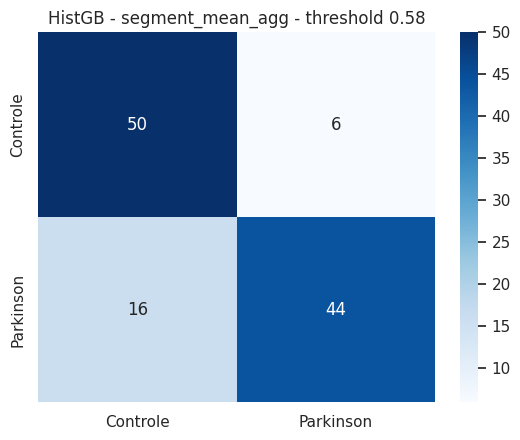

In [5]:
best=results_df.groupby(['level','model']).f1_macro.mean().sort_values(ascending=False).index[0]
print('best', best)
if best[0]=='session':
    best_model=models[best[1]]
    # Build OOF for session model
    X=session_features[feature_cols]; y=session_features.label.astype(int); groups=session_features.pID.astype(str)
    rows=[]
    for fold,(tr,va) in enumerate(cv.split(X,y,groups),1):
        clf=pipe(clone(best_model), smote=(best[1]!='HistGB'))
        clf.fit(X.iloc[tr], y.iloc[tr])
        proba=clf.predict_proba(X.iloc[va])[:,1]
        rows.append(session_features.iloc[va][['session_uid','pID','label']].assign(proba_mean=proba, fold=fold))
    best_oof=pd.concat(rows, ignore_index=True)
else:
    best_oof=oof_df[oof_df.model==best[1]].copy()

thresholds=np.linspace(.2,.8,61)
thr_rows=[]
for thr in thresholds:
    pred=(best_oof.proba_mean>=thr).astype(int)
    thr_rows.append({'threshold':thr,'f1_macro':f1_score(best_oof.label,pred,average='macro'),'balanced_accuracy':balanced_accuracy_score(best_oof.label,pred),'accuracy':accuracy_score(best_oof.label,pred)})
thr_df=pd.DataFrame(thr_rows)
best_thr=thr_df.sort_values('f1_macro', ascending=False).iloc[0]
display(thr_df.sort_values('f1_macro', ascending=False).head())

pred=(best_oof.proba_mean>=best_thr.threshold).astype(int)
print('chosen threshold', best_thr.threshold)
print(classification_report(best_oof.label,pred,target_names=['Controle','Parkinson']))
cm=confusion_matrix(best_oof.label,pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Controle','Parkinson'],yticklabels=['Controle','Parkinson'])
plt.title(f'{best[1]} - {best[0]} - threshold {best_thr.threshold:.2f}')
plt.show()

### Interpretation finale

Le meilleur modele est `HistGB` entraine sur segments, avec aggregation moyenne des probabilites par session. Le seuil par defaut 0.50 donne deja environ **0.80 F1 macro** en out-of-fold. Un seuil exploratoire a **0.58** monte a environ **0.81 F1 macro**.

Avec ce seuil, la matrice finale donne:

- controle: precision **0.76**, recall **0.89**, F1 **0.82**;
- Parkinson: precision **0.88**, recall **0.73**, F1 **0.80**;
- accuracy globale **0.81**.

C'est une vraie amelioration par rapport au notebook 01, mais le seuil est choisi sur les predictions out-of-fold: pour une app, il faudra le recalibrer sur une validation separee.

## 5. Export du meilleur modele

On exporte le pipeline final correspondant au meilleur modele observe. L'artefact garde aussi la liste des features et le seuil retenu en cross-validation exploratoire.

In [6]:
if best[0]=='session':
    train_df=session_features
else:
    train_df=segment_features
final_model=pipe(clone(models[best[1]]), smote=(best[1]!='HistGB'))
final_model.fit(train_df[feature_cols], train_df.label.astype(int))
artifact={'pipeline':final_model,'features':feature_cols,'model':best[1],'level':best[0],'threshold':float(best_thr.threshold),'note':'NeuroQWERTY v2 segmentation/features enriched; grouped CV by pID.'}
path=MODEL_DIR/'keyboard_dynamics_neuroqwerty_v2_pipeline.joblib'
joblib.dump(artifact,path)
print(path)

/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/models/keyboard_dynamics_neuroqwerty_v2_pipeline.joblib


## 6. Conclusion

Cette v2 ameliore la baseline NeuroQWERTY de facon credible. La meilleure version atteint environ **0.80 F1 macro moyen** en validation groupee par sujet, contre environ **0.75** dans le premier notebook.

La piste la plus prometteuse pour le test navigateur est donc:

1. collecter assez de frappes pour creer plusieurs segments;
2. extraire des features enrichies par segment;
3. predire chaque segment;
4. agreger les probabilites au niveau session/utilisateur;
5. afficher un score de risque calibre, pas une decision medicale.

Avant d'aller vers du deep learning, cette approche tabulaire segmentee est probablement la baseline principale a conserver.